In [ ]:
# @title
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["image.aspect"] = "auto"

# ------------------------------------------------------------
# Nastavenie dát:
# ROOT_DIR = koreňový priečinok, v ktorom má každá skladba vlastný podpriečinok
# napr.:
# /content/data/
#   ├── chopin/
#   │   ├── audio_times.npy
#   │   ├── audio_chroma.npy
#   │   ├── score_times.npy
#   │   ├── score_chroma.npy
#   │   ├── tempomap_raw.npy
#   │   ├── tempomap_smooth.npy
#   │   └── score_notes.csv
#   └── aka-si-mi-krasna/
#       └── ...
#
# SONG_NAME je len predvolená skladba.
# Potom môžeš volať show_alignment_segment(song_name="...", ...)
# opakovane pre rôzne skladby v rámci jedného notebooku.
# ------------------------------------------------------------
ROOT_DIR = "/content"
SONG_NAME = "palenocka"

REQUIRED_FILES = [
    "audio_times.npy",
    "audio_chroma.npy",
    "score_times.npy",
    "score_chroma.npy",
    "tempomap_raw.npy",
    "tempomap_smooth.npy",
    "score_notes.csv",
]

OPTIONAL_FILES = [
    "score_chroma_on_audio_time.npy",
    "score_chroma_warped_to_audio.npy",
    "path_frames.npy",
]


def is_song_bundle_dir(path):
    if not os.path.isdir(path):
        return False
    return all(os.path.exists(os.path.join(path, name)) for name in REQUIRED_FILES)


def list_song_dirs(root_dir):
    if not os.path.isdir(root_dir):
        return []
    out = []
    for name in sorted(os.listdir(root_dir)):
        full = os.path.join(root_dir, name)
        if is_song_bundle_dir(full):
            out.append(name)
    return out


def resolve_song_dir(root_dir, song_name=None):
    # 1) explicitne zvolená skladba: ROOT_DIR/SONG_NAME
    if song_name:
        candidate = os.path.join(root_dir, song_name)
        if is_song_bundle_dir(candidate):
            return candidate
        raise FileNotFoundError(
            f"Priečinok pre skladbu neexistuje alebo neobsahuje všetky potrebné súbory: {candidate}"
        )

    # 2) ROOT_DIR už priamo ukazuje na priečinok jednej skladby
    if is_song_bundle_dir(root_dir):
        return root_dir

    # 3) automatická detekcia podpriečinkov
    song_dirs = list_song_dirs(root_dir)
    if len(song_dirs) == 1:
        return os.path.join(root_dir, song_dirs[0])

    raise FileNotFoundError(
        "Nepodarilo sa určiť priečinok skladby. "
        f"Dostupné skladby v ROOT_DIR={root_dir!r}: {song_dirs}"
    )


AVAILABLE_SONGS = list_song_dirs(ROOT_DIR)
BUNDLE_DIR = resolve_song_dir(ROOT_DIR, SONG_NAME)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"Dostupné skladby: {AVAILABLE_SONGS}")
print(f"Predvolená skladba: {os.path.basename(BUNDLE_DIR)}")
print(f"Použitý priečinok: {BUNDLE_DIR}")


ROOT_DIR: /content
Dostupné skladby: ['palenocka']
Predvolená skladba: palenocka
Použitý priečinok: /content/palenocka


In [ ]:
# @title
def pick_existing(*paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("Nenašiel som žiadny z týchto súborov:\n" + "\n".join(paths))

def pick_optional(*paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

audio_times_path = pick_existing(os.path.join(BUNDLE_DIR, "audio_times.npy"))
audio_chroma_path = pick_existing(os.path.join(BUNDLE_DIR, "audio_chroma.npy"))
score_times_path = pick_existing(os.path.join(BUNDLE_DIR, "score_times.npy"))
score_chroma_path = pick_existing(os.path.join(BUNDLE_DIR, "score_chroma.npy"))

score_chroma_on_audio_path = pick_optional(
    os.path.join(BUNDLE_DIR, "score_chroma_on_audio_time.npy"),
    os.path.join(BUNDLE_DIR, "score_chroma_warped_to_audio.npy"),
)

path_frames_path = pick_optional(
    os.path.join(BUNDLE_DIR, "path_frames.npy"),
)

tempomap_raw_path = pick_existing(os.path.join(BUNDLE_DIR, "tempomap_raw.npy"))
tempomap_smooth_path = pick_existing(os.path.join(BUNDLE_DIR, "tempomap_smooth.npy"))
score_notes_csv_path = pick_existing(os.path.join(BUNDLE_DIR, "score_notes.csv"))

audio_times = np.load(audio_times_path, allow_pickle=True)
audio_chroma = np.load(audio_chroma_path, allow_pickle=True)
score_times = np.load(score_times_path, allow_pickle=True)
score_chroma = np.load(score_chroma_path, allow_pickle=True)

score_chroma_on_audio = None
if score_chroma_on_audio_path is not None:
    score_chroma_on_audio = np.load(score_chroma_on_audio_path, allow_pickle=True)

path_frames = None
if path_frames_path is not None:
    path_frames = np.load(path_frames_path, allow_pickle=True)

tempomap_raw = np.load(tempomap_raw_path, allow_pickle=True)
tempomap_smooth = np.load(tempomap_smooth_path, allow_pickle=True)
score_notes = pd.read_csv(score_notes_csv_path)


In [ ]:
# @title
audio_times = np.asarray(audio_times).squeeze()
score_times = np.asarray(score_times).squeeze()
audio_chroma = np.asarray(audio_chroma)
score_chroma = np.asarray(score_chroma)
tempomap_raw = np.asarray(tempomap_raw)
tempomap_smooth = np.asarray(tempomap_smooth)

if score_chroma_on_audio is not None:
    score_chroma_on_audio = np.asarray(score_chroma_on_audio)

if path_frames is not None:
    path_frames = np.asarray(path_frames)

def ensure_2d_time_major(X, expected_pitch_dim=12):
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"Očakával som 2D pole, ale dostal som shape={X.shape}")
    if X.shape[1] == expected_pitch_dim:
        return X
    if X.shape[0] == expected_pitch_dim:
        return X.T
    raise ValueError(f"Neviem určiť orientáciu chromy, shape={X.shape}")

audio_chroma = ensure_2d_time_major(audio_chroma, 12)
score_chroma = ensure_2d_time_major(score_chroma, 12)

if score_chroma_on_audio is not None:
    score_chroma_on_audio = ensure_2d_time_major(score_chroma_on_audio, 12)

def interp_score_from_audio(audio_sec, tempomap):
    tm = np.asarray(tempomap)
    score_t = tm[:, 0]
    audio_t = tm[:, 1]
    return np.interp(audio_sec, audio_t, score_t)

def slice_by_time(times, start, end):
    times = np.asarray(times)
    mask = (times >= start) & (times <= end)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, None, mask
    return idx[0], idx[-1] + 1, mask

def find_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None

def compute_score_chroma_on_audio_time_from_tempomap(
    score_times,
    score_chroma,
    audio_times,
    tempomap,
    normalize_rows=True,
):
    score_times = np.asarray(score_times).squeeze()
    score_chroma = np.asarray(score_chroma)
    audio_times = np.asarray(audio_times).squeeze()
    tempomap = np.asarray(tempomap)

    score_times_on_audio = np.interp(
        score_times,
        tempomap[:, 0],
        tempomap[:, 1],
    )

    order = np.argsort(score_times_on_audio)
    x = score_times_on_audio[order]
    Y = score_chroma[order]

    x_unique, unique_idx = np.unique(x, return_index=True)
    Y_unique = Y[unique_idx]

    warped = np.zeros((len(audio_times), score_chroma.shape[1]), dtype=float)

    for pc in range(score_chroma.shape[1]):
        warped[:, pc] = np.interp(
            audio_times,
            x_unique,
            Y_unique[:, pc],
            left=0.0,
            right=0.0,
        )

    if normalize_rows:
        norms = np.linalg.norm(warped, axis=1, keepdims=True)
        norms[norms == 0.0] = 1.0
        warped = warped / norms

    return warped

def normalize_bundle(bundle):
    bundle = dict(bundle)
    bundle["audio_times"] = np.asarray(bundle["audio_times"]).squeeze()
    bundle["score_times"] = np.asarray(bundle["score_times"]).squeeze()
    bundle["audio_chroma"] = ensure_2d_time_major(np.asarray(bundle["audio_chroma"]), 12)
    bundle["score_chroma"] = ensure_2d_time_major(np.asarray(bundle["score_chroma"]), 12)
    bundle["tempomap_raw"] = np.asarray(bundle["tempomap_raw"])
    bundle["tempomap_smooth"] = np.asarray(bundle["tempomap_smooth"])

    if bundle.get("score_chroma_on_audio") is not None:
        bundle["score_chroma_on_audio"] = ensure_2d_time_major(
            np.asarray(bundle["score_chroma_on_audio"]), 12
        )

    if bundle.get("path_frames") is not None:
        bundle["path_frames"] = np.asarray(bundle["path_frames"])

    return bundle

def load_song_bundle(root_dir, song_name):
    bundle_dir = resolve_song_dir(root_dir, song_name)

    audio_times_path = pick_existing(os.path.join(bundle_dir, "audio_times.npy"))
    audio_chroma_path = pick_existing(os.path.join(bundle_dir, "audio_chroma.npy"))
    score_times_path = pick_existing(os.path.join(bundle_dir, "score_times.npy"))
    score_chroma_path = pick_existing(os.path.join(bundle_dir, "score_chroma.npy"))

    score_chroma_on_audio_path = pick_optional(
        os.path.join(bundle_dir, "score_chroma_on_audio_time.npy"),
        os.path.join(bundle_dir, "score_chroma_warped_to_audio.npy"),
    )

    path_frames_path = pick_optional(
        os.path.join(bundle_dir, "path_frames.npy"),
    )

    tempomap_raw_path = pick_existing(os.path.join(bundle_dir, "tempomap_raw.npy"))
    tempomap_smooth_path = pick_existing(os.path.join(bundle_dir, "tempomap_smooth.npy"))
    score_notes_csv_path = pick_existing(os.path.join(bundle_dir, "score_notes.csv"))

    bundle = {
        "bundle_dir": bundle_dir,
        "audio_times": np.load(audio_times_path, allow_pickle=True),
        "audio_chroma": np.load(audio_chroma_path, allow_pickle=True),
        "score_times": np.load(score_times_path, allow_pickle=True),
        "score_chroma": np.load(score_chroma_path, allow_pickle=True),
        "score_chroma_on_audio": None,
        "path_frames": None,
        "tempomap_raw": np.load(tempomap_raw_path, allow_pickle=True),
        "tempomap_smooth": np.load(tempomap_smooth_path, allow_pickle=True),
        "score_notes": pd.read_csv(score_notes_csv_path),
    }

    if score_chroma_on_audio_path is not None:
        bundle["score_chroma_on_audio"] = np.load(score_chroma_on_audio_path, allow_pickle=True)

    if path_frames_path is not None:
        bundle["path_frames"] = np.load(path_frames_path, allow_pickle=True)

    return normalize_bundle(bundle)

_current_song_name = os.path.basename(BUNDLE_DIR)
_song_cache = {
    _current_song_name: normalize_bundle({
        "bundle_dir": BUNDLE_DIR,
        "audio_times": audio_times,
        "audio_chroma": audio_chroma,
        "score_times": score_times,
        "score_chroma": score_chroma,
        "score_chroma_on_audio": score_chroma_on_audio,
        "path_frames": path_frames,
        "tempomap_raw": tempomap_raw,
        "tempomap_smooth": tempomap_smooth,
        "score_notes": score_notes,
    })
}

def use_song(song_name=None):
    global BUNDLE_DIR
    global audio_times, audio_chroma, score_times, score_chroma
    global score_chroma_on_audio, path_frames
    global tempomap_raw, tempomap_smooth, score_notes
    global _current_song_name

    if song_name is None:
        song_name = _current_song_name

    if song_name not in _song_cache:
        _song_cache[song_name] = load_song_bundle(ROOT_DIR, song_name)

    d = _song_cache[song_name]

    BUNDLE_DIR = d["bundle_dir"]
    audio_times = d["audio_times"]
    audio_chroma = d["audio_chroma"]
    score_times = d["score_times"]
    score_chroma = d["score_chroma"]
    score_chroma_on_audio = d["score_chroma_on_audio"]
    path_frames = d["path_frames"]
    tempomap_raw = d["tempomap_raw"]
    tempomap_smooth = d["tempomap_smooth"]
    score_notes = d["score_notes"]
    _current_song_name = song_name

    return song_name

print(f"Cache pripravená pre skladbu: {_current_song_name}")


Cache pripravená pre skladbu: palenocka


In [ ]:
# @title
def show_alignment_segment(
    song_name=None,
    audio_start=0.0,
    audio_end=10.0,
    use_smoothed_tempomap=True,
    show_audio_player=False,
    save_prefix=None,
):
    active_song = use_song(song_name)
    tempomap = tempomap_smooth if use_smoothed_tempomap else tempomap_raw

    score_start = interp_score_from_audio(audio_start, tempomap)
    score_end = interp_score_from_audio(audio_end, tempomap)

    print(f"Skladba: {active_song}")
    print(f"Audio úsek: {audio_start:.3f} – {audio_end:.3f} s")
    print(f"Score úsek: {score_start:.3f} – {score_end:.3f} beat")

    if show_audio_player:
        print("Audio prehrávač je v tejto verzii notebooku vypnutý — .wav súbor netreba nahrávať.")

    a0, a1, _ = slice_by_time(audio_times, audio_start, audio_end)
    if a0 is None:
        raise ValueError("Vybraný audio úsek je mimo audio časovej osi.")

    audio_times_seg = audio_times[a0:a1]
    audio_chroma_seg = audio_chroma[a0:a1]

    s0, s1, _ = slice_by_time(score_times, score_start, score_end)
    if s0 is None:
        raise ValueError("Vybraný score úsek je mimo score časovej osi.")

    score_times_seg = score_times[s0:s1]
    score_chroma_seg = score_chroma[s0:s1]

    if score_chroma_on_audio is not None:
        score_chroma_on_audio_sec = score_chroma_on_audio
    else:
        score_chroma_on_audio_sec = compute_score_chroma_on_audio_time_from_tempomap(
            score_times=score_times,
            score_chroma=score_chroma,
            audio_times=audio_times,
            tempomap=tempomap,
            normalize_rows=True,
        )

    warped_seg = score_chroma_on_audio_sec[a0:a1]

    tm = np.asarray(tempomap)
    tm_mask = (tm[:, 1] >= audio_start) & (tm[:, 1] <= audio_end)
    tm_seg = tm[tm_mask]

    col_onset = find_col(score_notes, ["onset_beat", "onset", "score_time"])
    col_dur = find_col(score_notes, ["duration_beat", "duration"])
    col_pitch = find_col(score_notes, ["pitch", "midi_pitch"])

    if col_onset is None or col_dur is None or col_pitch is None:
        raise ValueError(f"V score_notes.csv chýbajú potrebné stĺpce. Dostupné: {list(score_notes.columns)}")

    notes_seg = score_notes[
        (score_notes[col_onset] + score_notes[col_dur] >= score_start) &
        (score_notes[col_onset] <= score_end)
    ].copy()

    local_cost = 1.0 - np.clip(score_chroma_seg @ audio_chroma_seg.T, -1.0, 1.0)

    local_path = None
    if path_frames is not None:
        pf = np.asarray(path_frames)
        mask = (
            (pf[:, 0] >= s0) & (pf[:, 0] < s1) &
            (pf[:, 1] >= a0) & (pf[:, 1] < a1)
        )
        local_path = pf[mask].copy()
        if len(local_path) > 0:
            local_path[:, 0] -= s0
            local_path[:, 1] -= a0

    fig1, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].imshow(
        warped_seg.T,
        origin="lower",
        aspect="auto",
        extent=[audio_times_seg[0], audio_times_seg[-1], 0, 11],
    )
    axes[0].set_title(f"Score chroma premapovaná na audio čas [s] — {active_song}")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Pitch class")

    axes[1].imshow(
        audio_chroma_seg.T,
        origin="lower",
        aspect="auto",
        extent=[audio_times_seg[0], audio_times_seg[-1], 0, 11],
    )
    axes[1].set_title("Audio chroma [s]")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel("Pitch class")

    if len(tm_seg) > 0:
        axes[2].plot(tm_seg[:, 0], tm_seg[:, 1], linewidth=2)
    axes[2].set_title("Lokálna tempomapa")
    axes[2].set_xlabel("Score time [beat]")
    axes[2].set_ylabel("Audio time [s]")

    plt.tight_layout()
    plt.show()

    fig3 = plt.figure(figsize=(9, 6))
    plt.imshow(
        local_cost,
        origin="lower",
        aspect="auto",
        extent=[audio_times_seg[0], audio_times_seg[-1], score_times_seg[0], score_times_seg[-1]],
    )

    if local_path is not None and len(local_path) > 0:
        x = audio_times_seg[local_path[:, 1]]
        y = score_times_seg[local_path[:, 0]]
        plt.plot(x, y, color="red", linewidth=2.5)

    plt.xlabel("Audio time [s]")
    plt.ylabel("Score time [beat]")
    plt.title(f"Lokálna cost matrix s warping path — {active_song}")
    plt.show()

    print("Lokálny počet note events:", len(notes_seg))
    print("Lokálny shape cost matrix:", local_cost.shape)
    print("Lokálny počet path bodov:", 0 if local_path is None else len(local_path))

    if save_prefix is not None:
        os.makedirs(os.path.dirname(save_prefix), exist_ok=True)
        fig1.savefig(f"{save_prefix}_01_chromas_tempomap.png", dpi=150, bbox_inches="tight")
        fig3.savefig(f"{save_prefix}_03_cost_path.png", dpi=150, bbox_inches="tight")


**Aká si mi krásna - koniec frázy**

Skladba: aka-si-mi-krasna
Audio úsek: 0.000 – 25.000 s
Score úsek: 0.000 – 16.942 beat


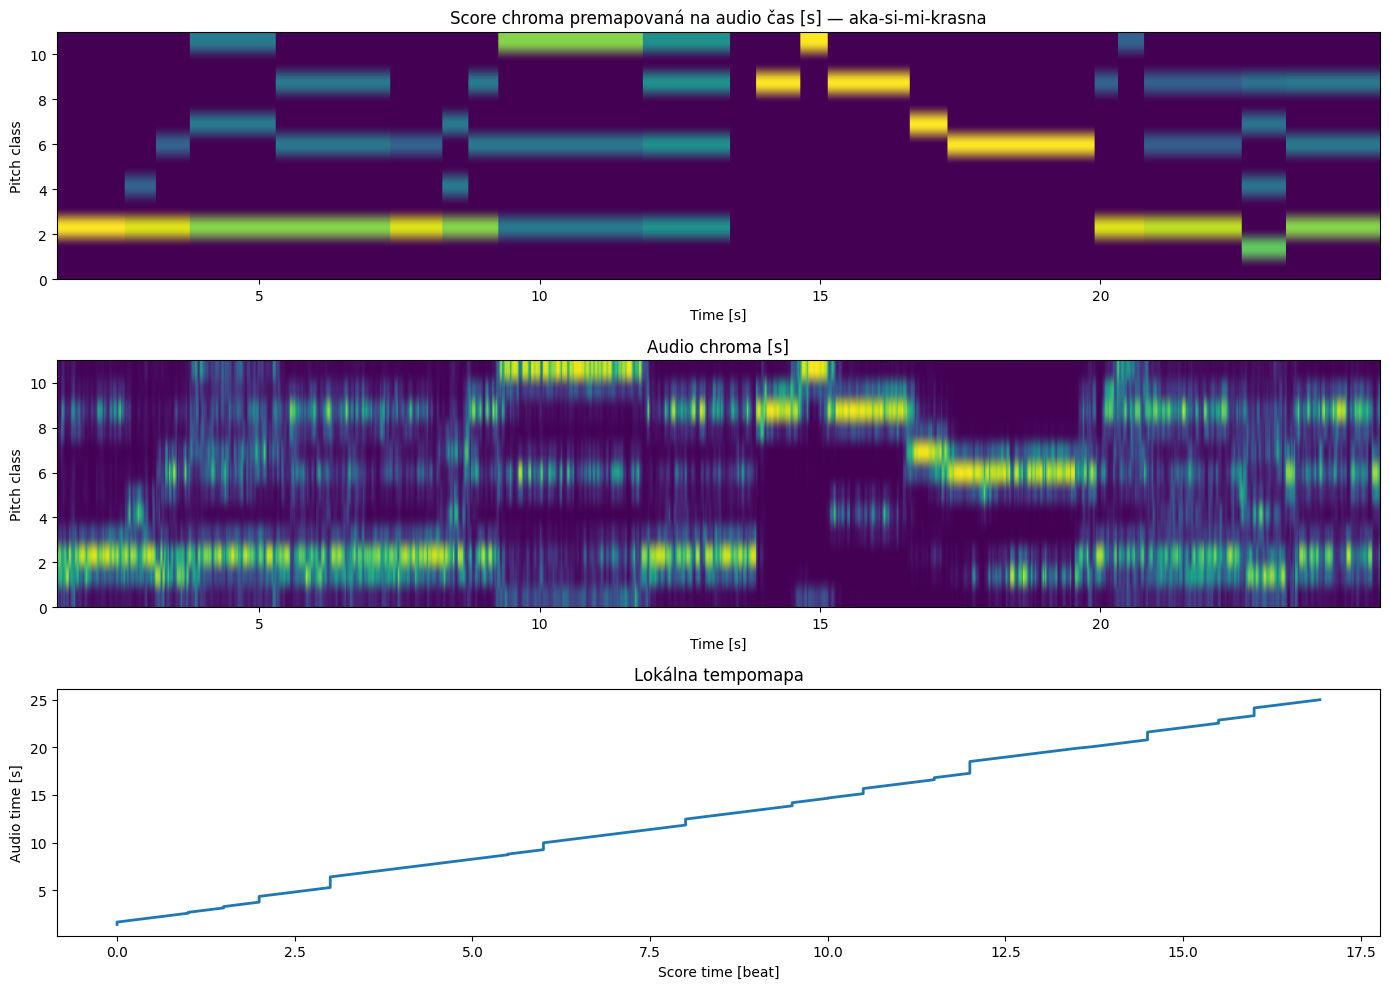

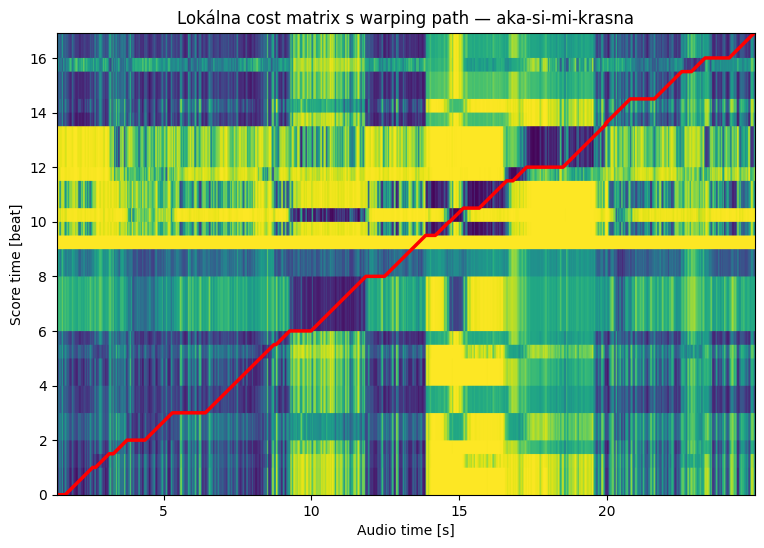

Lokálny počet note events: 79
Lokálny shape cost matrix: (678, 1017)
Lokálny počet path bodov: 1019
Skladba: aka-si-mi-krasna_transposed
Audio úsek: 0.000 – 25.000 s
Score úsek: 0.000 – 16.000 beat


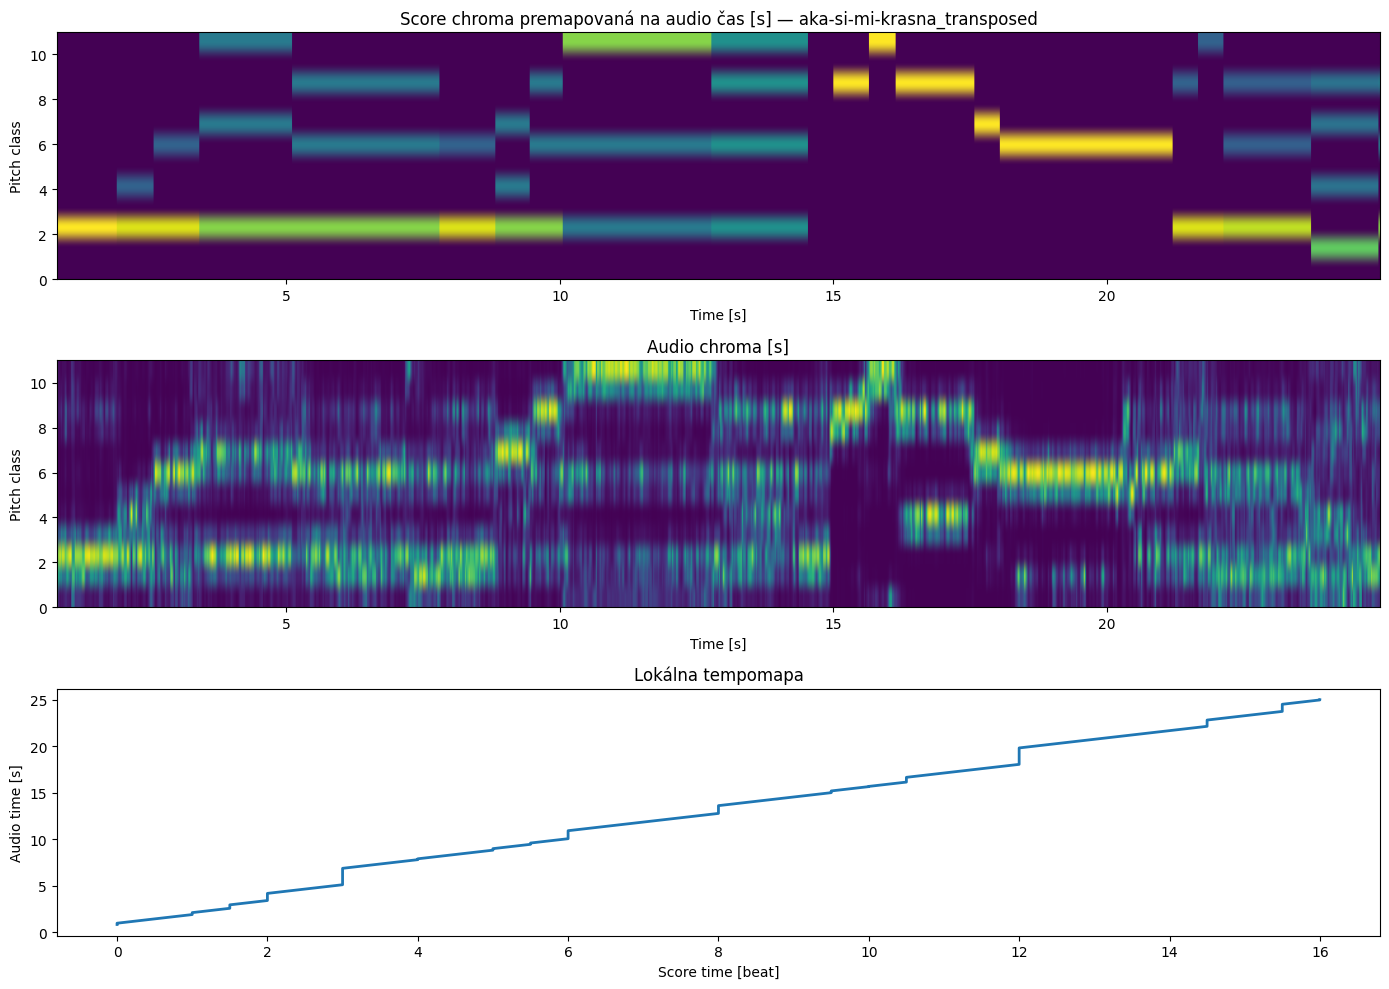

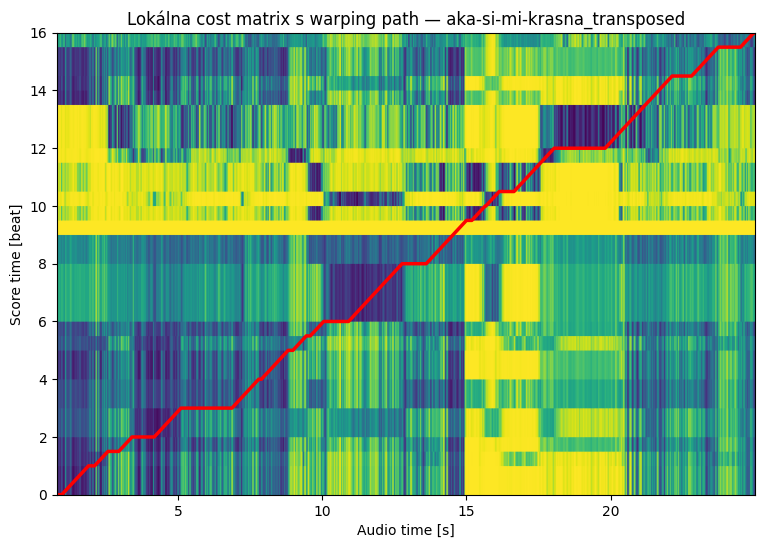

Lokálny počet note events: 75
Lokálny shape cost matrix: (641, 1042)
Lokálny počet path bodov: 1042


In [ ]:
show_alignment_segment(
    song_name="aka-si-mi-krasna",
    audio_start=0,
    audio_end=25.0,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

show_alignment_segment(
    song_name="aka-si-mi-krasna_transposed",
    audio_start=0,
    audio_end=25.0,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

**Aká si mi krásna - opakované tóny**

Skladba: aka-si-mi-krasna
Audio úsek: 45.000 – 75.000 s
Score úsek: 32.450 – 52.500 beat


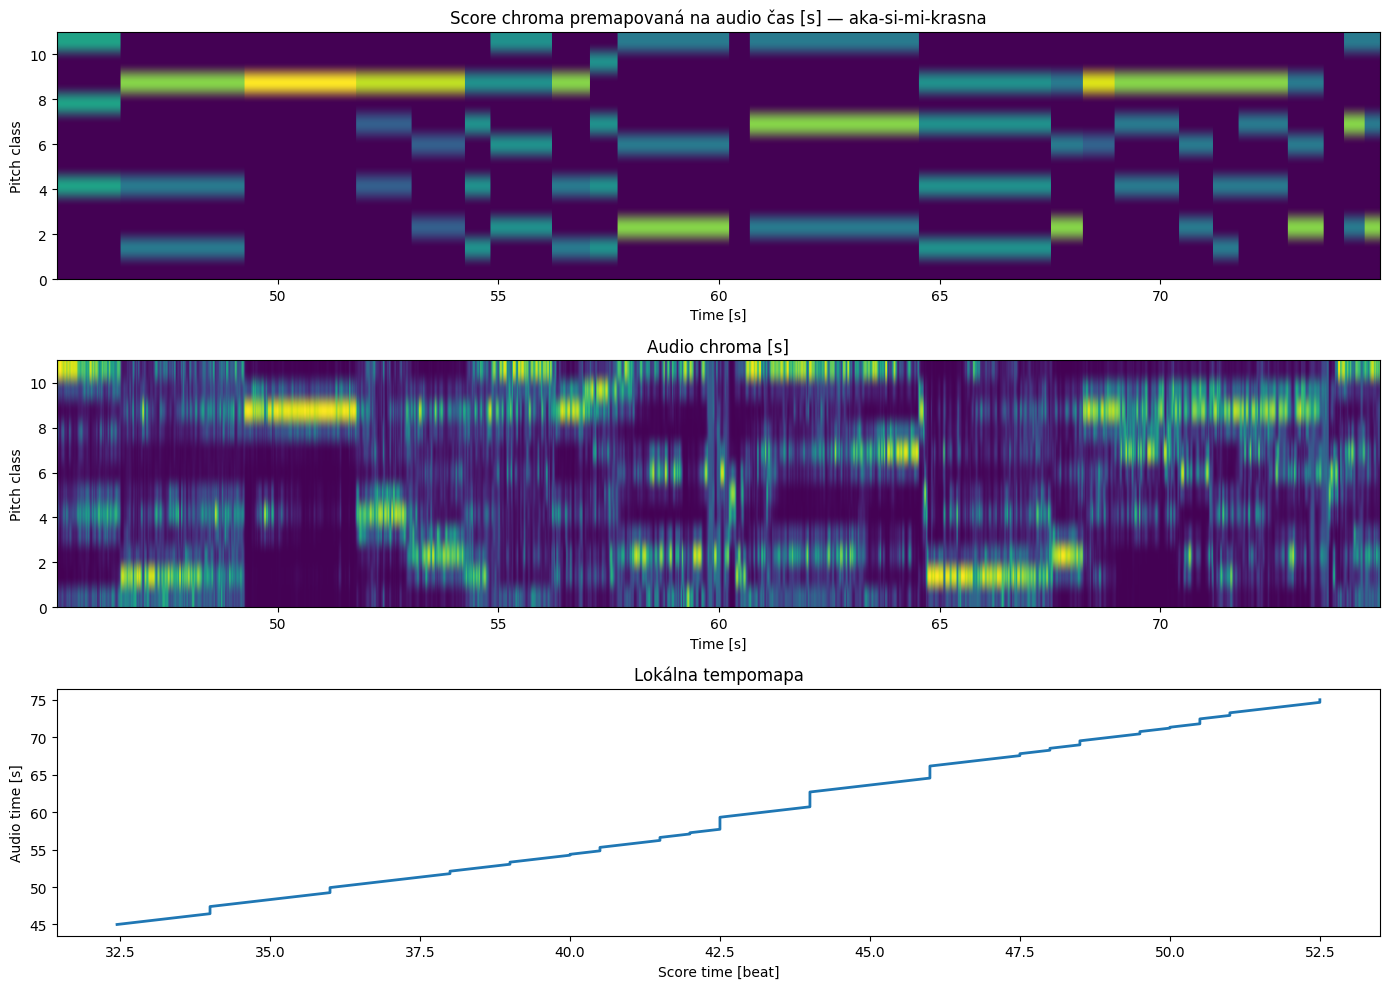

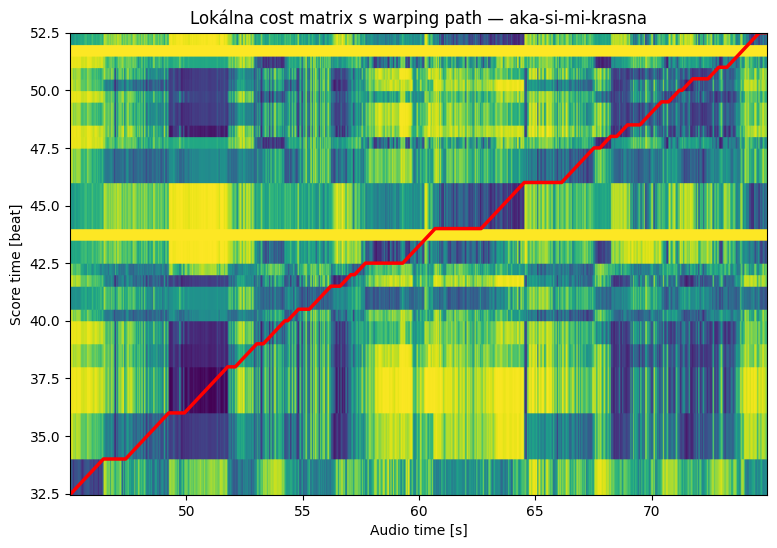

Lokálny počet note events: 116
Lokálny shape cost matrix: (803, 1292)
Lokálny počet path bodov: 1292
Skladba: aka-si-mi-krasna_transposed
Audio úsek: 45.000 – 75.000 s
Score úsek: 30.025 – 51.650 beat


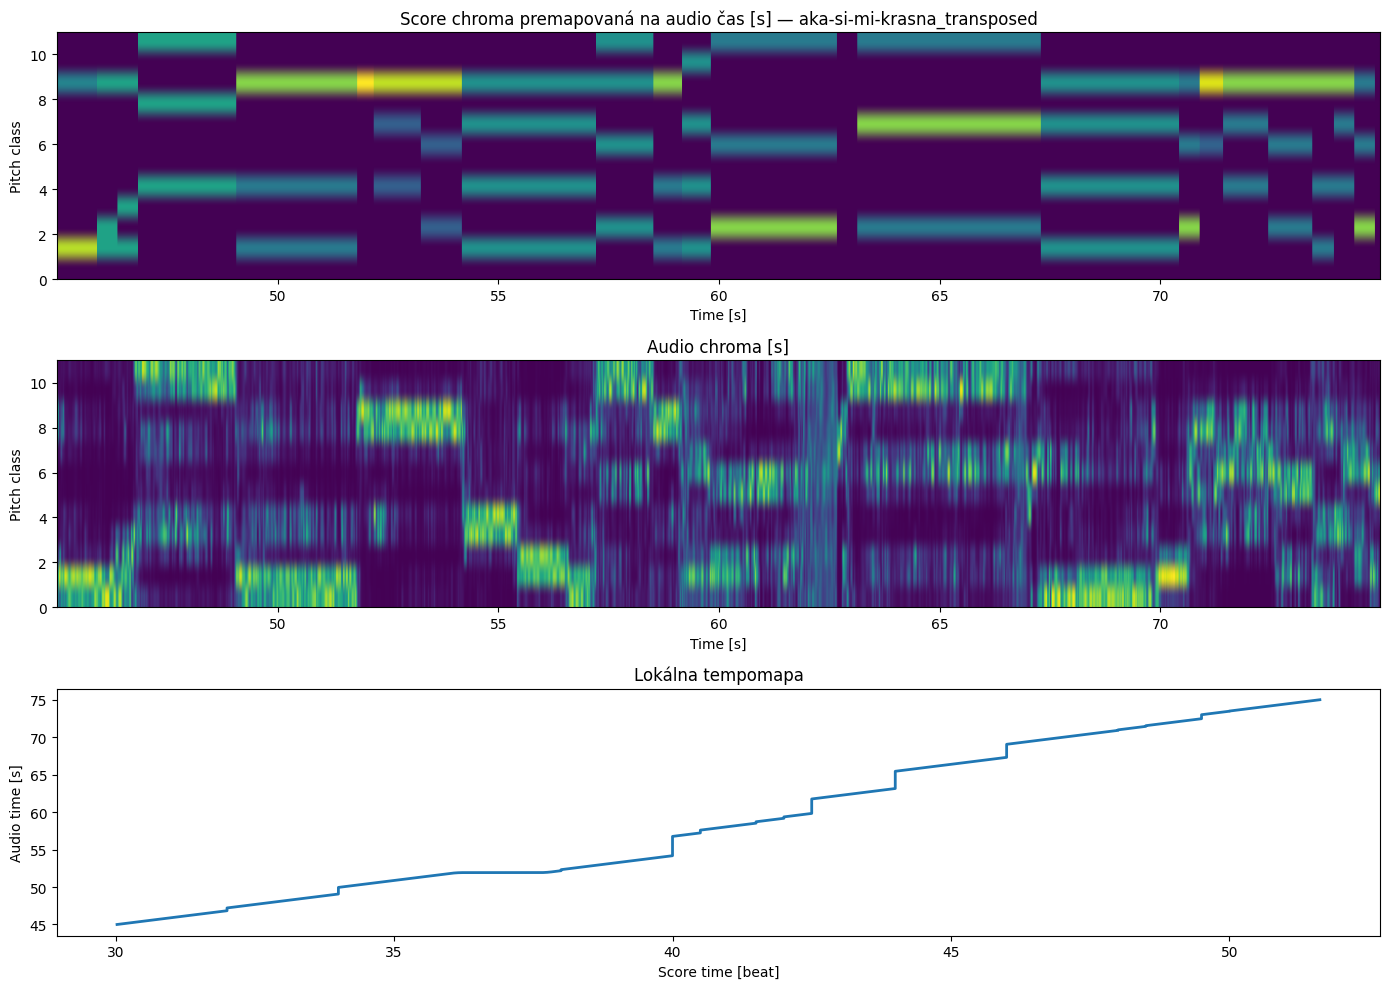

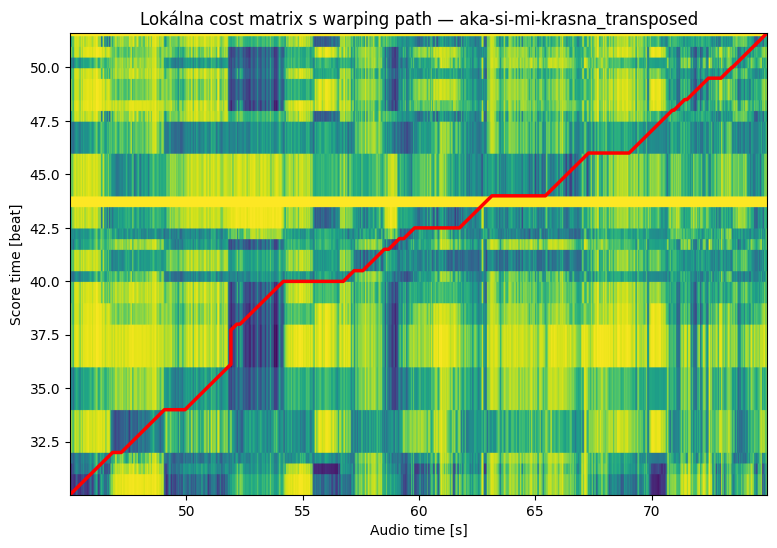

Lokálny počet note events: 116
Lokálny shape cost matrix: (865, 1292)
Lokálny počet path bodov: 1356


In [ ]:
show_alignment_segment(
    song_name="aka-si-mi-krasna",
    audio_start=45,
    audio_end=75,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

show_alignment_segment(
    song_name="aka-si-mi-krasna_transposed",
    audio_start=45,
    audio_end=75,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

**Pálenočka - koniec**

Skladba: palenocka
Audio úsek: 85.000 – 100.000 s
Score úsek: 193.190 – 215.999 beat


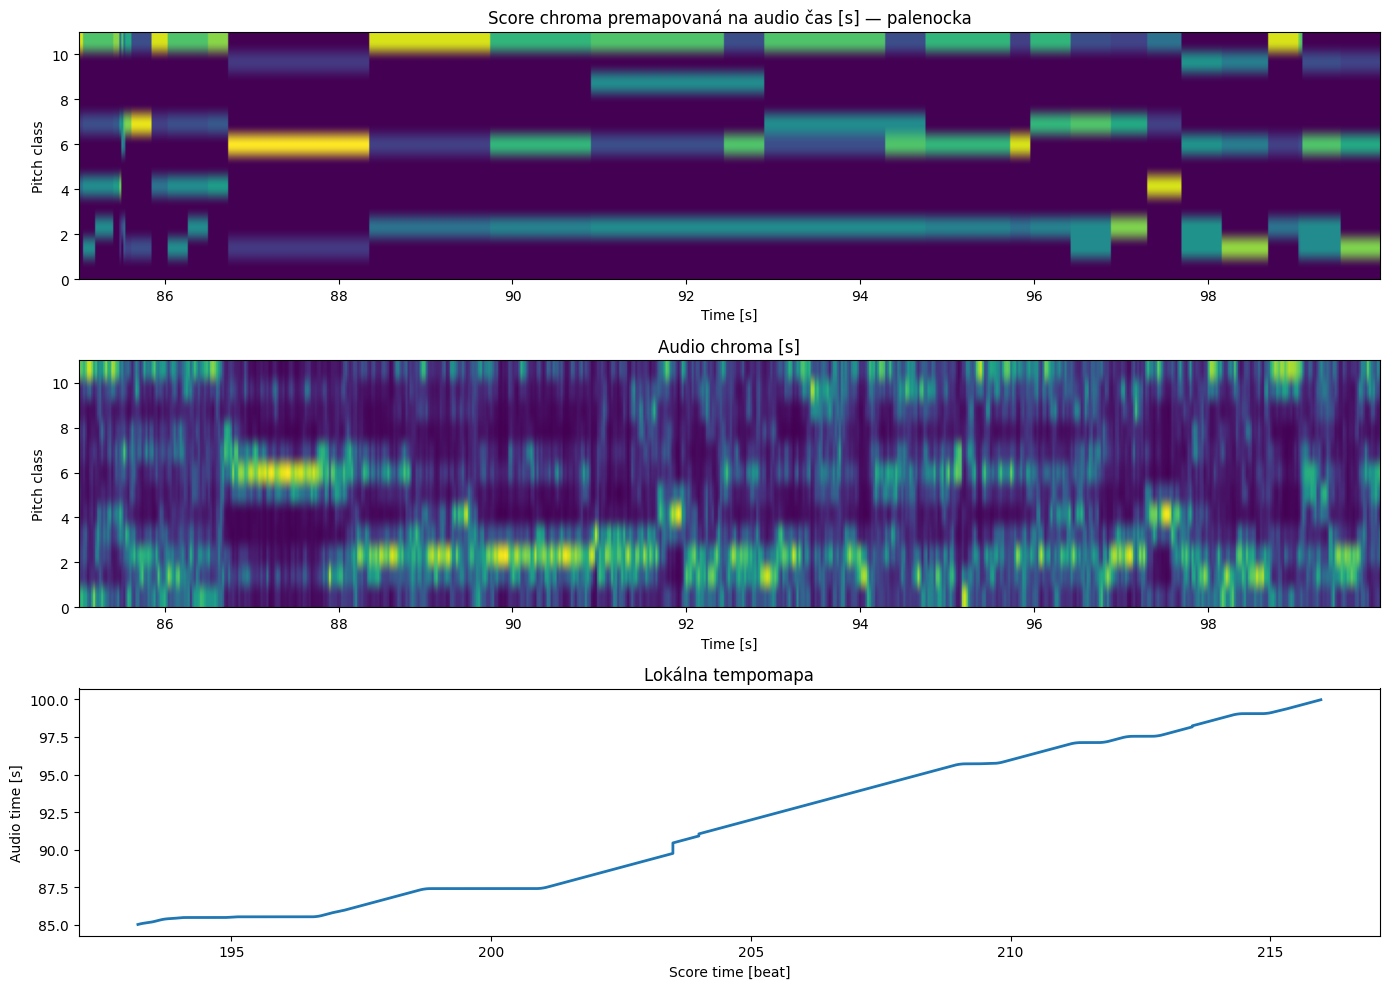

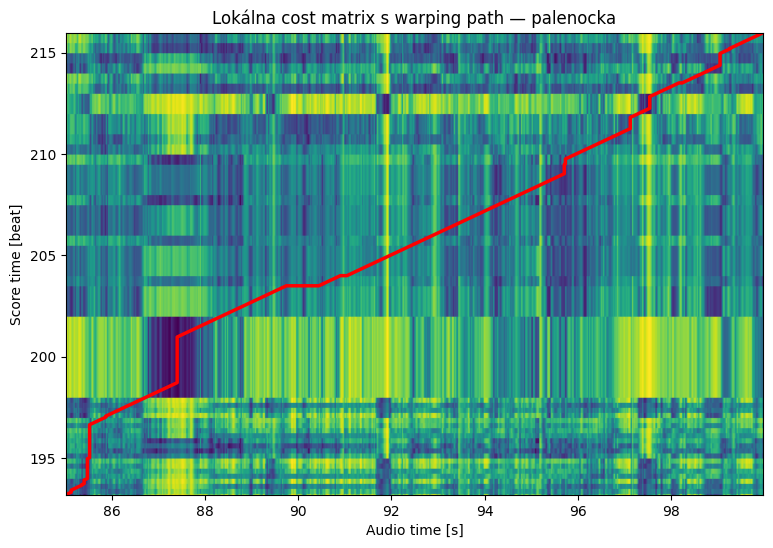

Lokálny počet note events: 222
Lokálny shape cost matrix: (912, 646)
Lokálny počet path bodov: 951
Skladba: palenocka
Audio úsek: 100.000 – 115.000 s
Score úsek: 215.999 – 234.000 beat


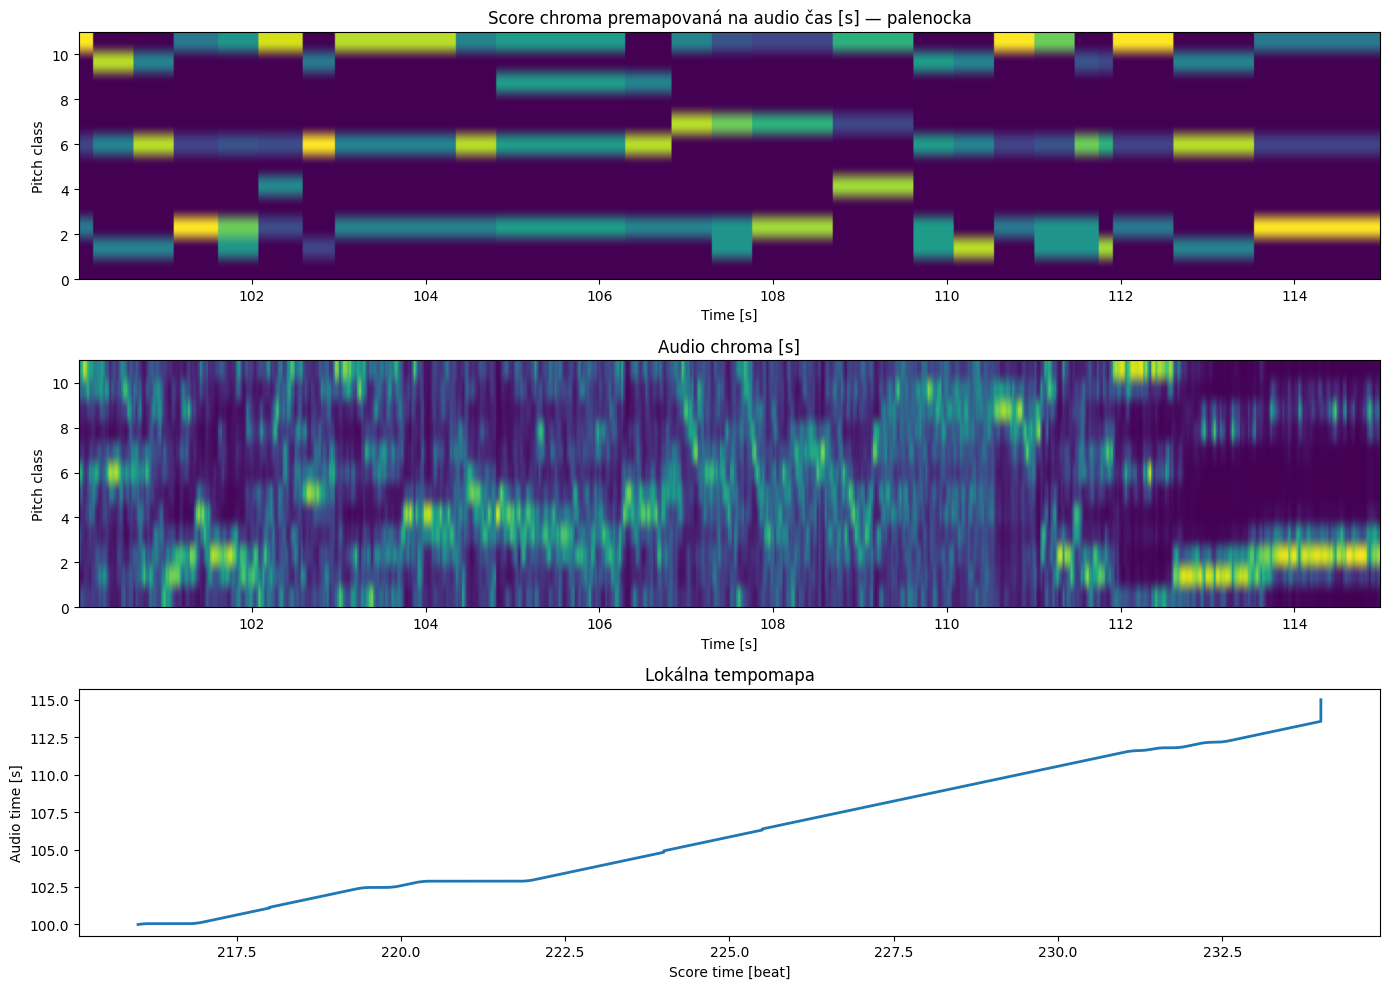

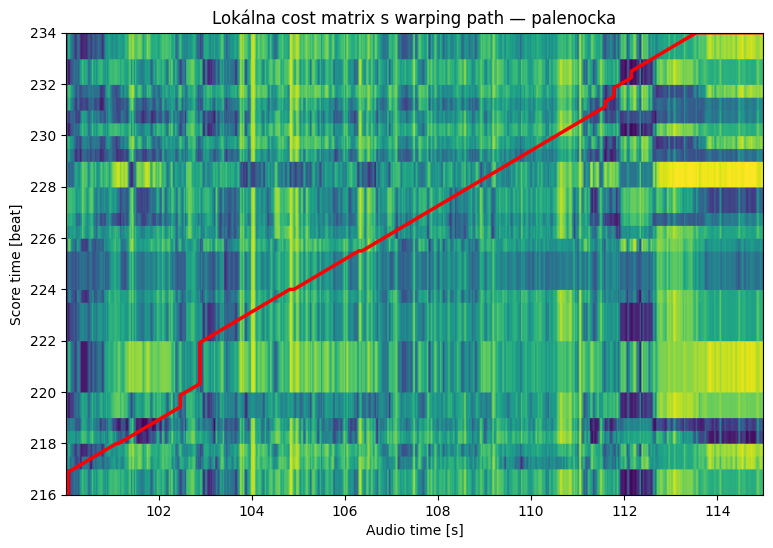

Lokálny počet note events: 208
Lokálny shape cost matrix: (721, 646)
Lokálny počet path bodov: 792
Skladba: palenocka
Audio úsek: 88.000 – 92.000 s
Score úsek: 201.621 – 205.028 beat


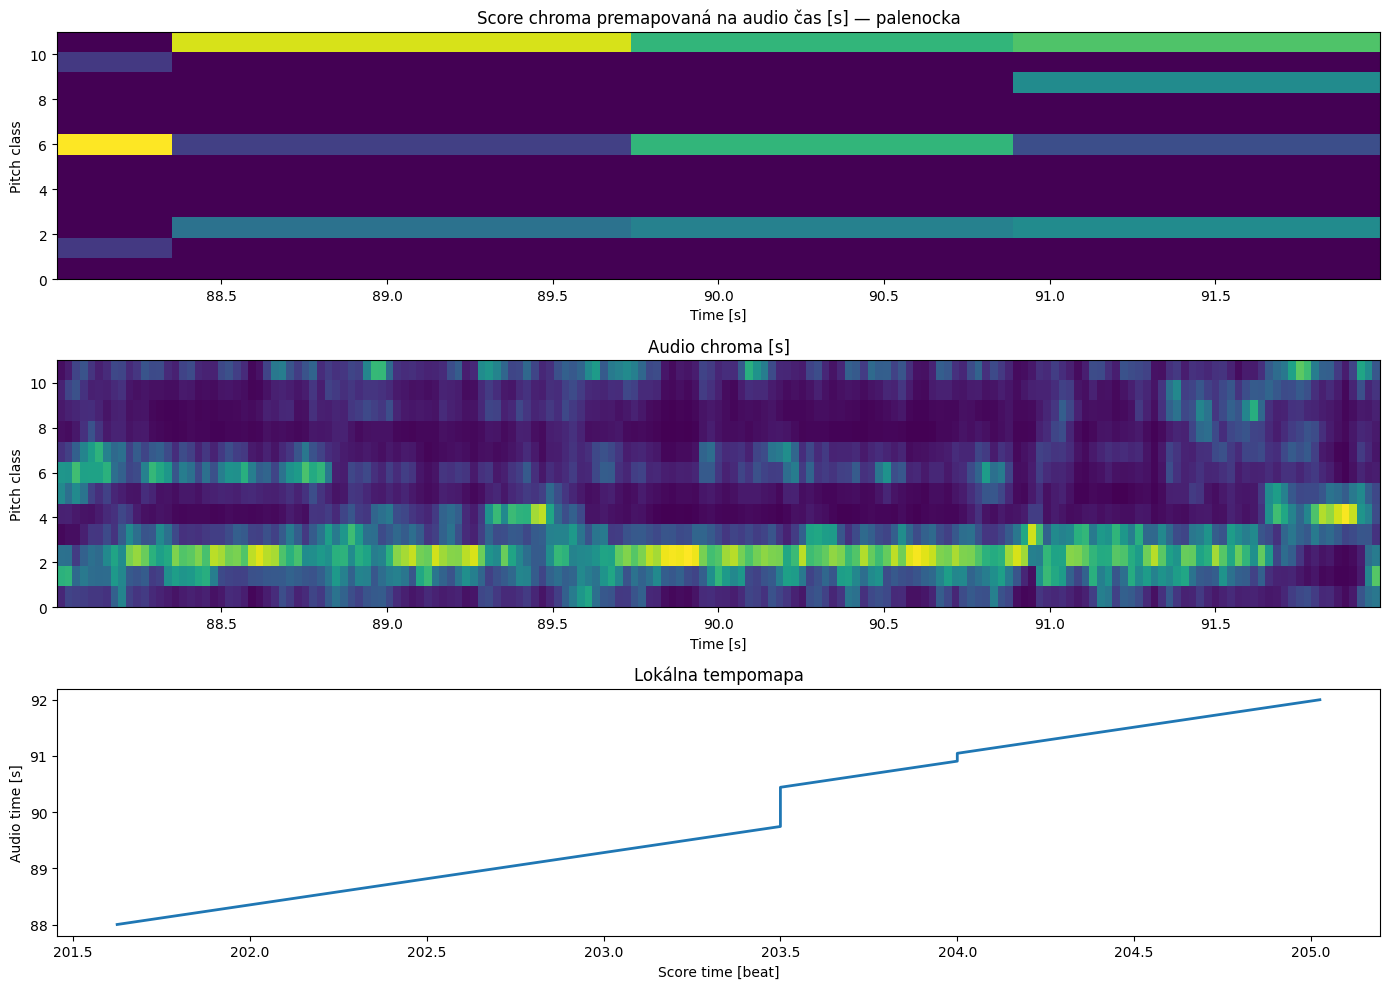

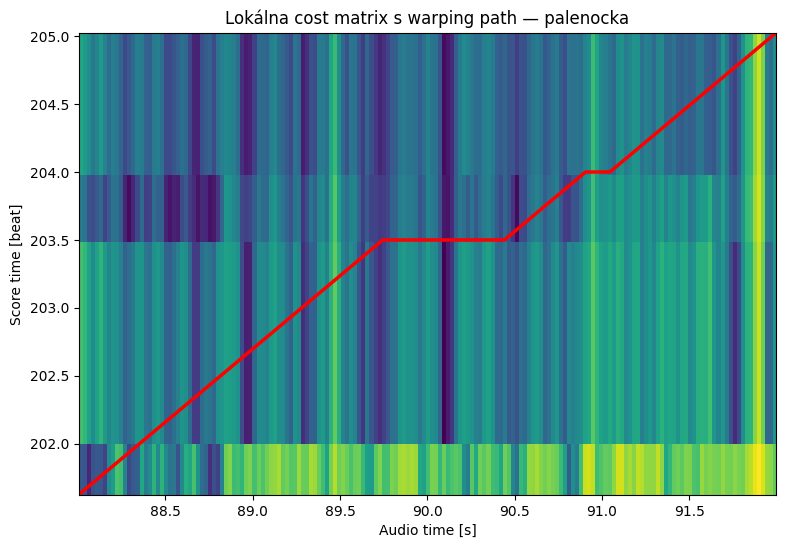

Lokálny počet note events: 34
Lokálny shape cost matrix: (137, 173)
Lokálny počet path bodov: 173


In [ ]:
show_alignment_segment(
    song_name="palenocka",
    audio_start=85,
    audio_end=100,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

show_alignment_segment(
    song_name="palenocka",
    audio_start=100,
    audio_end=115,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)

show_alignment_segment(
    song_name="palenocka",
    audio_start=88,
    audio_end=92,
    use_smoothed_tempomap=True,
    show_audio_player=False,
)